In [278]:
import importlib
import numpy as np
import sys
import urllib.request
import matplotlib.pyplot as plt
sys.path.append('../')
import deep_learning.model
#importlib.reload(deep_learning.model)
#importlib.reload(deep_learning.utils)
from deep_learning.utils import train_test_split,to_one_hot,plot_learning_curve,plot_neuron_heatmap
from deep_learning.model import MLP,Dense,Softmax,CrossEntropy,ReLU # import my implmentation

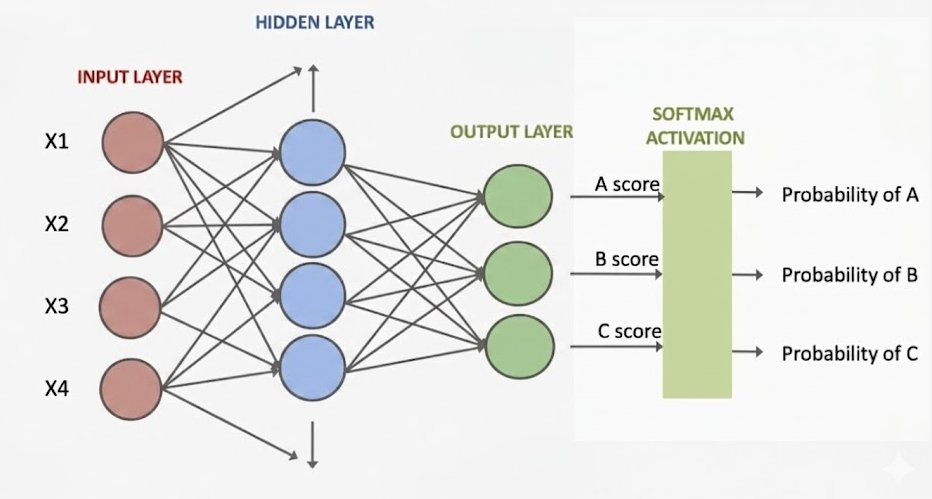

In [279]:
# Iris dataset : The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
urllib.request.urlretrieve(url, "iris.csv")  # download


In [280]:
data = np.genfromtxt("iris.csv", delimiter=",", dtype=str)  # read
class_names = np.unique(data[:, 4])
class_names

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype='<U15')

In [281]:
class_names_dict = {}
for index, class_name in enumerate(class_names):
    class_names_dict[class_name] = index
  

In [282]:
X = data[:, 0:4].astype(float) # shape (150, 4)

In [283]:
y=np.array([class_names_dict[i] for i in data[:, 4]]) # shape (150,)


In [284]:
import matplotlib.pyplot as plt


def plot_data(X, y, class_names, xlim=None, ylim=None):
      
    fig, ax = plt.subplots()

    # Fixed or auto limits
    xlim = xlim or (X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
    ylim = ylim or (X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Plot points
    for cls, marker, label in [(0, 'o', class_names[0]), (1, 's', class_names[1]),(2, '^', class_names[2])]:
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], marker=marker, label=label)
 

    ax.legend()
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    plt.show()

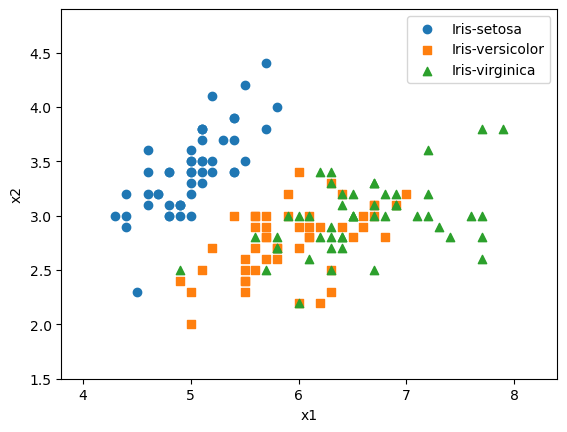

In [285]:
plot_data(X, y,class_names) # showing just 2 features, we can see classes are not linearly separable

In [286]:
SEED = 24
(X_train, X_test, y_train, y_test) = train_test_split(X, y, 0.1, SEED)

In [287]:
# normalization by feature
X_min, X_max = X_train.min(axis=0), X_train.max(axis=0) # row colapse
X_train = (X_train - X_min) / (X_max - X_min)
X_test = (X_test - X_min) / (X_max - X_min)

In [288]:
y_train_one_hot=to_one_hot(y_train,len(class_names))
y_test_one_hot=to_one_hot(y_test,len(class_names))

In [289]:
EPOCHS = 2000
LR = 0.1

model = MLP(layers=[
    Dense(inputs=X_train.shape[1], neurons=8, activation_function=ReLU(), lr=LR, seed=SEED),
    Dense(inputs=8, neurons=3, activation_function=Softmax(), lr=LR, seed=SEED)
], loss_function=CrossEntropy())


In [290]:
loss = model.train(X_train, y_train_one_hot, epochs=EPOCHS,batch_size=len(X_train))
for index, epoch_loss in enumerate(loss):
    if index % 10 == 0:
        print(f"Epoch: {index+1} | Loss: {epoch_loss}")
#print(f'Loss: {loss[-1]}')

Epoch: 1 | Loss: 1.098523126666826
Epoch: 11 | Loss: 1.0978566570696868
Epoch: 21 | Loss: 1.0974239618417576
Epoch: 31 | Loss: 1.0970358512766443
Epoch: 41 | Loss: 1.0965739100418035
Epoch: 51 | Loss: 1.0959237472532006
Epoch: 61 | Loss: 1.094904478526365
Epoch: 71 | Loss: 1.0932575761012429
Epoch: 81 | Loss: 1.0905751890965483
Epoch: 91 | Loss: 1.0862190977404984
Epoch: 101 | Loss: 1.0792166698033177
Epoch: 111 | Loss: 1.0681699507810545
Epoch: 121 | Loss: 1.0512783593633972
Epoch: 131 | Loss: 1.026618975465799
Epoch: 141 | Loss: 0.9929528102081339
Epoch: 151 | Loss: 0.9506132623557025
Epoch: 161 | Loss: 0.9018263499708861
Epoch: 171 | Loss: 0.850208722028829
Epoch: 181 | Loss: 0.7988462004789818
Epoch: 191 | Loss: 0.7498551803073913
Epoch: 201 | Loss: 0.7041050119471168
Epoch: 211 | Loss: 0.6623385481727532
Epoch: 221 | Loss: 0.6246782765249005
Epoch: 231 | Loss: 0.5911244241673929
Epoch: 241 | Loss: 0.5615255053048603
Epoch: 251 | Loss: 0.5355094733238559
Epoch: 261 | Loss: 0.512601

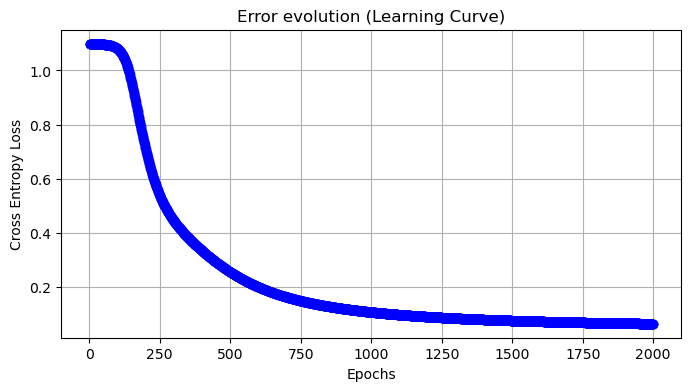

In [291]:
plot_learning_curve(loss, ylabel='Cross Entropy Loss')

In [292]:
probs = model.predict(X_test)      
preds=np.argmax(probs,axis=1)

In [293]:
for  pred, yi in zip( preds, y_test):
    print(f"true: {class_names[int(yi)]}  prediction: {class_names[pred]} ")

accuracy = np.mean(preds == y_test)
print(f"Accuracy: {accuracy:.2%}")

true: Iris-setosa  prediction: Iris-setosa 
true: Iris-virginica  prediction: Iris-virginica 
true: Iris-virginica  prediction: Iris-virginica 
true: Iris-virginica  prediction: Iris-virginica 
true: Iris-setosa  prediction: Iris-setosa 
true: Iris-virginica  prediction: Iris-virginica 
true: Iris-virginica  prediction: Iris-virginica 
true: Iris-setosa  prediction: Iris-setosa 
true: Iris-versicolor  prediction: Iris-versicolor 
true: Iris-virginica  prediction: Iris-virginica 
true: Iris-virginica  prediction: Iris-virginica 
true: Iris-setosa  prediction: Iris-setosa 
true: Iris-versicolor  prediction: Iris-versicolor 
true: Iris-versicolor  prediction: Iris-versicolor 
true: Iris-virginica  prediction: Iris-virginica 
Accuracy: 100.00%
